<a href="https://colab.research.google.com/github/janpeter19/BPL_TEST2_Batch/blob/main/BPL_TEST2_Batch_oms_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BPL_TEST2_Batch script with OMSimulator

The key library OMSimulator is installed.

After the installation a small application BPL_TEST2_Batch is loaded and run. You can continue with this example if you like.

In [1]:
!lsb_release -a # Actual VM Ubuntu version used by Google

No LSB modules are available.
Distributor ID:	Ubuntu
Description:	Ubuntu 24.04.5 LTS
Release:	24.04
Codename:	noble


In [2]:
!python --version

Python 3.13.15


In [3]:
!pip install OMSimulator

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for OMSimulator: filename=omsimulator-3.0.0.post116-py3-none-any.whl size=1345325 sha256=28d96a489f9a28d0c0807f06b23213ee2439c4190183dc72b29144dfb4db4360
  Stored in directory: /root/.cache/pip/wheels/eb/b0/ee/5194adbcfe75a2efc0262c5c0377b28ecbc648628be707b5a4
Successfully built OMSimulator


# BPL_TEST2_Batch setup


Now specific installation and the run simulations. Start with connecting to Github. Then upload the two files:

* FMU - BPL_TEST2_Batch_linux_om_me.fmu
* Setup-file - BPL_TEST2_Batch_fmpy_explore.py

In [4]:
%%bash
git clone https://github.com/janpeter19/BPL_TEST2_Batch

Cloning into 'BPL_TEST2_Batch'...


In [5]:
%cd BPL_TEST2_Batch

/content/BPL_TEST2_Batch


## BPL_TEST2_Batch - demo



In [6]:
import OMSimulator as oms

In [7]:
import scipy.io

In [8]:
import matplotlib.pyplot as plt

In [9]:
fmu = oms.FMU('BPL_TEST2_Batch_linux_om_me.fmu')

In [10]:
fmu.modelName

'BPL.Examples_TEST2.Batch'

In [11]:
for s in fmu.states:
  print(s.name)

bioreactor.V
bioreactor.m[1]
bioreactor.m[2]


In [12]:
help(fmu)

Help on FMU in module OMSimulator.fmu object:

class FMU(builtins.object)
 |  FMU(fmu_path: Union[str, pathlib._local.Path], instanceName: str = None)
 |
 |  Methods defined here:
 |
 |  __init__(
 |      self,
 |      fmu_path: Union[str, pathlib._local.Path],
 |      instanceName: str = None
 |  )
 |      Initialize the FMU by loading modelDescription.xml from the FMU archive.
 |
 |  delete(self)
 |
 |  dumpApiCalls(self)
 |      Returns the generated API calls as a string.
 |
 |  exportSSMTemplate(self, filename: pathlib._local.Path | None = None)
 |
 |  exportSSVTemplate(self, filename: pathlib._local.Path | None = None)
 |
 |  export_units_to_ssd(self, node)
 |      Exports all unit definitions to an SSD XML node.
 |
 |  getValue(self, cref: str)
 |
 |  initialize(self)
 |
 |  instantiate(self)
 |      Instantiate the FMU for simulation.
 |
 |  makeConnectors(self)
 |
 |  setDefaultExperiment(self)
 |
 |  setLogFile(self, filename: str)
 |
 |  setLoggingInterval(self, interval: fl

In [13]:
fmu.instantiate()

In [14]:
fmu.setResultFile('result.mat')

In [15]:
fmu.setValue('bioreactor.V', 1.0)
fmu.setValue('bioreactor.m_start[1]', 1.0)
fmu.setValue('bioreactor.m_start[2]', 10.0)

RuntimeError: Failed to set value for Batch.root.Batch.bioreactor.V: Status.warning

In [16]:
fmu.initialize()

In [17]:
fmu.simulate()

In [18]:
mat_data = scipy.io.loadmat('result.mat')

In [19]:
mat_data.keys()

dict_keys(['Aclass', 'name', 'description', 'dataInfo', 'data_1', 'data_2'])

In [20]:
mat_data['Aclass']

array(['Atrajectory', '1.1', '', 'binTrans'], dtype='<U11')

In [21]:
t = mat_data['data_2'][0];

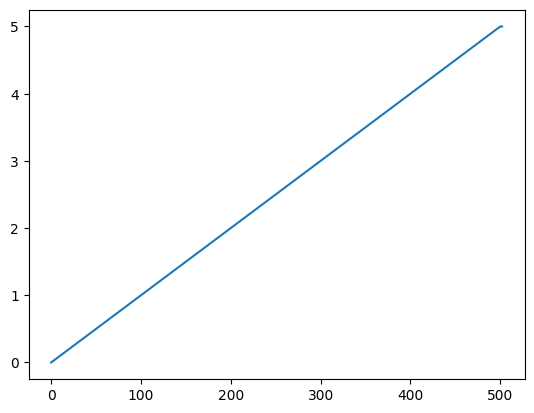

In [23]:
plt.figure()
plt.plot(mat_data['data_2'][0])

Simulation time is apparently store in "0". The other "columns" show just constants. I think the initial values of the states need to be set different from zero which is default.